# Sentiment classification

In [79]:
import pandas as pd

df = pd.read_csv("C:/Users/yasmine/Documents/neps/neps-ml-ai/data/preprocessed/clean_nlp_data.csv")

#### Imports + Train/Test Split

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import joblib
import os

y = df["sentiment_manual"]

X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text_final"],
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

#### TF-IDF Vectorization

In [81]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

#### Train Model

In [82]:
model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


#### Evaluation

In [83]:
preds = model.predict(X_test_tfidf)

print(classification_report(y_test, preds))

                 precision    recall  f1-score   support

mildly_negative       1.00      1.00      1.00        60
mildly_positive       1.00      1.00      1.00        44
       negative       1.00      1.00      1.00       200
        neutral       1.00      1.00      1.00        40
       positive       1.00      0.98      0.99        56

       accuracy                           1.00       400
      macro avg       1.00      1.00      1.00       400
   weighted avg       1.00      1.00      1.00       400



#### Confusion Matrix

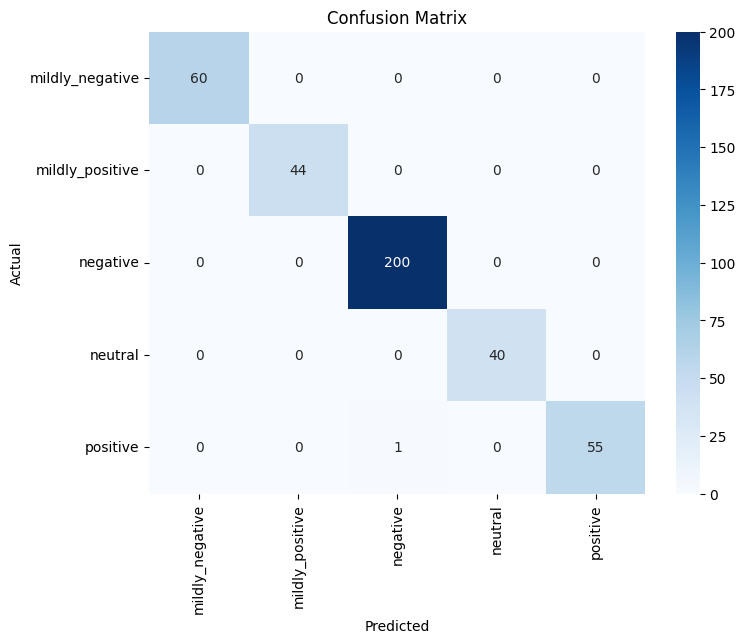

In [84]:
y_pred = model.predict(X_test_tfidf)

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#### Feature Importance

In [85]:
feature_names = vectorizer.get_feature_names_out()

for i, cls in enumerate(model.classes_):
    
    top_idx = model.coef_[i].argsort()[-15:]
    
    print("\nCLASS:", cls)
    print([feature_names[j] for j in top_idx])


CLASS: mildly_negative
['food', 'missed', 'frustrating', 'ticket', 'program', 'like im', 'important', 'making', 'late', 'seems', 'need', 'interested', 'disappointing', 'money', 'wanted']

CLASS: mildly_positive
['parttime', 'least talking', 'close least', 'falling close', 'reconnected friend', 'friend falling', 'win', 'semester', 'one', 'slightly', 'week', 'better', 'great', 'progress', 'least']

CLASS: negative
['alone', 'thought', 'alive', 'people', 'pain', 'every', 'like', 'loneliness', 'numbness', 'emptiness', 'guilt', 'fear', 'anger', 'shame', 'cant']

CLASS: neutral
['academic', 'class', 'day', 'im sure', 'sure', 'schedule packed', 'packed class', 'packed', 'work dont', 'class work', 'new', 'situation', 'adequate', 'current', 'neither']

CLASS: positive
['growing', 'today', 'together', 'paid', 'read', 'confidence', 'grateful', 'content', 'love', 'community', 'contentment', 'calm', 'finally', 'im proud', 'proud']


#### Error analysis

In [86]:
df_test = X_test.copy()
df_test = pd.DataFrame({
    "text": X_test,
    "true": y_test,
    "pred": y_pred
})

df_test[df_test["true"] != df_test["pred"]].head(10)

,text,true,pred
423,feel deeply loved chosen family blood doesnt d...,positive,negative


#### Save Model + Vectorizer

In [89]:
joblib.dump(model, "C:\\Users\\yasmine\\Documents\\neps\\neps-ml-ai\\models\\sentiment_model.pkl")
joblib.dump(vectorizer, "C:\\Users\\yasmine\\Documents\\neps\\neps-ml-ai\\models\\sentiment_vectorizer.pkl")

['C:\\Users\\yasmine\\Documents\\neps\\neps-ml-ai\\models\\sentiment_vectorizer.pkl']

#### Save Pipeline

In [90]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=10000,
        ngram_range=(1,2)
    )),
    ("clf", LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    ))
])

pipeline.fit(df["clean_text"], df["sentiment_manual"])

joblib.dump(pipeline, "C:\\Users\\yasmine\\Documents\\neps\\neps-ml-ai\\models\\sentiment_pipeline.pkl")

['C:\\Users\\yasmine\\Documents\\neps\\neps-ml-ai\\models\\sentiment_pipeline.pkl']